### Simplificação da rede viária 

Resultado esperado:
- Geometria simplificada com o uso da biblioteca neatnet.neatify 
- GeoPackage/GeoParquet com a nova geometria

In [1]:
# Instala dependencias
%pip install geopandas pyogrio shapely neatnet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# Bibliotecas 
import geopandas as gpd
import pyogrio as ogr
import shapely as shp
import neatnet
import pathlib
import matplotlib.pyplot as plt
import osmnx as ox
import json

import networkx as nx

%matplotlib inline


In [29]:
# Carrega o arquivo de json de configuração
#   open -> inputs: arquivo, modo de abertura, codificação
with open("../config/config.json", "r", encoding="utf-8") as config_file:
    config = json.load(config_file)

# Configurações
study_area = config["study_area"]
crs = study_area["crs"]

cidade = study_area["place"]
network_type = study_area["network_type"]

Carrega rede

In [3]:
# Rede Bom Fim
graph = ox.load_graphml("../data/graph/rede-bomFim.graphml")


Carrega origens

In [4]:
# Carrega origens
origens = gpd.read_file(
    "../data/o-d/origens_porto_alegre.gpkg",
    layer="origens"
)

In [5]:
# Verificar se a rede é formada por mais de um componente
componentes = list(nx.weakly_connected_components(graph))

print("Número de componentes:", len(componentes))


Número de componentes: 1


Se nmr de componentes > 1

In [6]:
# Gera os componentes fracamente conectados
componentes = sorted(
    nx.weakly_connected_components(graph),
    key=len,
    reverse=True
)

# Quantos nós tem cada componente
for i, componente in enumerate(componentes):
    print(f"Componente {i}: {len(componente)} nós")

Componente 0: 55 nós


-------------------------
**Exemplo de resultado**

Componente 0: 125430 nós

Componente 1: 18 nós

Componente 2: 7 nós

Componente 3: 3 nós

*Interpretação: Isso já sugere que o componente 0 é a rede principal e os outros são pequenos trechos isolados*

-------------------------

Verifica se as origens estão na rede principal

Passar etapa que cria origens do bairro para arquivo '03'

In [56]:
# Carrega arquivo com os bairros
bairros = gpd.read_file("../data/bairros/Bairros_LC12112_16.shp")

# Verifica sistema de coordenadas
print(bairros.crs)
#print(bairros.geometry.crs)

PROJCS["TM-POA",GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6674"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.999995],PARAMETER["false_easting",300000],PARAMETER["false_northing",5000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [ ]:


# Converte o sistema de coordenadas para EPSG:31982
bairros = bairros.set_crs(origens.crs, allow_override=True)

# Converte skp para gpkg
bairros.to_file(
    "../data/bairros/bairros.gpkg",
    layer="bairros",
    driver="GPKG"
)

bairros.head()

PROJCS["TM-POA",GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6674"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.999995],PARAMETER["false_easting",300000],PARAMETER["false_northing",5000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
PROJCS["TM-POA",GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6674"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.999995],PARAMETER["false_easting",300000],PARAMETER["false_northing",500

,OBJECTID,CODIGO,NOME,EDITOR,DATA_EDICA,GEOM_AREA,GEOM_LEN,geometry
0,1281,0,PASSO DAS PEDRAS,None,2016-10-20,0.0,0.0,"POLYGON ((287595.213 1678609.133, 287635.971 1..."
1,1282,0,HIGIENÓPOLIS,None,2016-10-20,0.0,0.0,"POLYGON ((282819.328 1677715.723, 282809.697 1..."
2,1283,0,VILA IPIRANGA,None,2016-10-20,0.0,0.0,"POLYGON ((285882.786 1676864.358, 285806.568 1..."
3,1288,0,PARQUE SANTA FÉ,None,2016-10-20,0.0,0.0,"POLYGON ((290475.978 1679356.214, 290477.321 1..."
4,1289,0,COSTA E SILVA,None,2016-10-20,0.0,0.0,"POLYGON ((289403.688 1679659.969, 289400.081 1..."


In [52]:
# REVER
# Seleciona o Bom Fim
bomfim = bairros[bairros["NOME"] == "BOM FIM"]
print(bomfim.crs)
print(bomfim.geometry.iloc[0])
print(bomfim.geometry.area)




# Cria polígono do Bom Fim
bomfim_geometry = bomfim.geometry.iloc[0]
#print(bomfim_geometry)
print(origens.crs)
print(origens.geometry.head())

origens_bomfim = origens[origens.geometry.within(bomfim_geometry)]
print(origens_bomfim)

origens_bomfim = origens[origens.geometry.within(bomfim.geometry.iloc[0])]

"""
origens_bomfim.to_file(
    "../data/o-d/origens_bomfim.gpkg",
    layer="origens_bomfim",
    driver="GPKG"
)
print(bomfim)
print(bomfim.geometry.iloc[0])
print(bomfim.geometry.area)
"""

EPSG:31982
POLYGON ((279907.2313000001 1675789.2403999995, 279882.29110000003 1675794.0180000002, 279865.63719999976 1675797.8720000004, 279854.2555999998 1675802.2659, 279844.93850000016 1675806.1303000003, 279813.6814000001 1675820.0214, 279767.6190999998 1675847.0557000004, 279731.89300000016 1675869.1734999996, 279676.0278000003 1675901.7062999997, 279660.3038999997 1675909.9495, 279642.6853 1675921.8000999996, 279597.8607000001 1675948.6654000003, 279458.17200000025 1676031.3793000001, 279368.3033999996 1676083.7216999996, 279304.95050000027 1676121.5456999997, 279226.4951999998 1676168.5190000003, 279213.1102 1676173.5462999996, 279148.0385999996 1676190.5888999999, 279041.37349999975 1676217.5232999995, 278959.73670000024 1676238.0941000003, 278958.6113 1676238.3777, 278877.38350000046 1676258.7592000002, 278860.7103000004 1676262.3427999998, 278852.1311999997 1676264.1868000003, 278827.8136 1676271.3546000002, 278760.0603 1676288.4414999997, 278729.50270000007 1676298.515200000

'\norigens_bomfim.to_file(\n    "../data/o-d/origens_bomfim.gpkg",\n    layer="origens_bomfim",\n    driver="GPKG"\n)\nprint(bomfim)\nprint(bomfim.geometry.iloc[0])\nprint(bomfim.geometry.area)\n'

In [53]:
print("Bounds bairros:")
print(bairros.total_bounds)

print("Bounds origens:")
print(origens.total_bounds)

print("Área real do Bom Fim:")
print(bomfim.geometry.area)

print(origens.geometry.head())
print(bairros.geometry.head())

Bounds bairros:
[ 271062.9491 1650035.8874  298900.2456 1687546.4623]
Bounds origens:
[ 473856.72696696 6652239.14044548  498744.37742289 6686325.7469253 ]
Área real do Bom Fim:
51    495368.374076
dtype: float64
0    POINT (474386.204 6669552.438)
1     POINT (474578.68 6669554.914)
2     POINT (474383.84 6669760.062)
3    POINT (474576.318 6669762.539)
4    POINT (474381.475 6669967.684)
Name: geometry, dtype: geometry
0    POLYGON ((287595.213 1678609.133, 287635.971 1...
1    POLYGON ((282819.328 1677715.723, 282809.697 1...
2    POLYGON ((285882.786 1676864.358, 285806.568 1...
3    POLYGON ((290475.978 1679356.214, 290477.321 1...
4    POLYGON ((289403.688 1679659.969, 289400.081 1...
Name: geometry, dtype: geometry


In [54]:
print("CRS bairros:")
print(bairros.crs)

print("\nCRS origens:")
print(origens.crs)

print("\nCRS bomfim:")
print(bomfim.crs)

CRS bairros:
EPSG:31982

CRS origens:
EPSG:31982

CRS bomfim:
EPSG:31982


C:\Users\Simone\AppData\Local\Temp\ipykernel_40176\1238795459.py:25: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


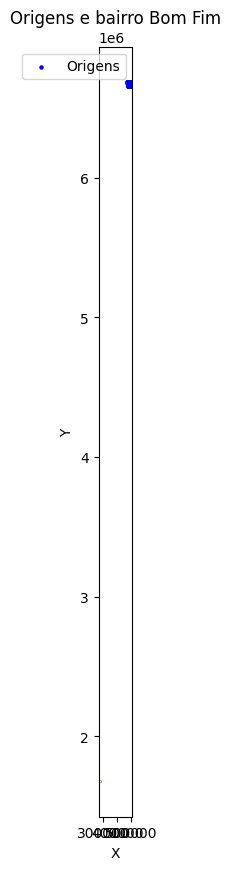

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Plota todas as origens
origens.plot(
    ax=ax,
    color="blue",
    markersize=5,
    label="Origens"
)

# Plota o polígono do Bom Fim
bomfim.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    label="Bom Fim"
)

ax.set_title("Origens e bairro Bom Fim")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()

plt.show()

In [15]:
print(len(origens))
print(len(origens_bomfim))

6189
0


In [14]:
print("bairros:", bairros.crs)
print("bomfim:", bomfim.crs)
print("origens:", origens.crs)
print("origens_bomfim:", origens_bomfim.crs)
print("grid:", grid.crs)

bairros: EPSG:31982
bomfim: EPSG:31982
origens: EPSG:31982
origens_bomfim: EPSG:31982
grid: EPSG:31982


In [9]:

# Cria um dicionário que mapeia cada nó para o índice do componente ao qual ele pertence
node_to_component = {}

for i, componente in enumerate(componentes):
    for node in componente:
        node_to_component[node] = i

origens["componente"] = origens["node"].map(node_to_component)

print(origens[["origin_id", "node", "componente"]])
origens["componente"].unique()

      origin_id        node  componente
0         235.0  2248442166         NaN
1         236.0   296249745         NaN
2         237.0  2248442166         NaN
3         238.0   508060554         NaN
4         239.0   583532859         NaN
...         ...         ...         ...
6184    12866.0  8658562772         NaN
6185    12869.0  8658562772         NaN
6186    12871.0  8658562772         NaN
6187    12872.0  8658562772         NaN
6188    12875.0  1011917815         NaN

[6189 rows x 3 columns]


array([nan,  0.])

In [10]:
print(type(graph))
node = origens.iloc[0]["node"]

print(node)
print(node in graph.nodes)
origens["node"].isin(graph.nodes).value_counts()

<class 'networkx.classes.multidigraph.MultiDiGraph'>
2248442166
False


node
False    6174
True       15
Name: count, dtype: int64